In [1]:

import json
import pandas as pd
import matplotlib.pyplot as plt
import sys
import os
# sys.path.insert(0,'..')
sys.path.insert(0,'../..')

In [2]:
COLORS = [
    "#ffd7b3", # orange
    "#cce1e4", # green
    "#d9d9d9", # grey
    ]

PROPOSED_MFE_PREFS = [
            "adwin_",
            "dbscan_",
            "ddm_",
            "dc_",
            "hddma_",
            "hddmw_",
            "kmeans_",
            "kswin_",
            "omv_pth_",
            "psi_",
            "u_detect_",
            "overlap_",
            "_ks_statistic",
            "_ks_pvalue",
            "sqsi_drift_flag",
            "predict",
            "last",
        ]

FINAL_FEATURE_FRACTION = {'powersupply': 50, 
                        #   'airlines': 65, 
                          'electricity': 15, 
                        #   'rialto': 10
                          }

In [ ]:

TYPE_DICT = {"with_drift": "proposed_mtl", "without_drift": "original_mtl"}

def get_bar_color(row):
    if any(substr in row["feature"] for substr in PROPOSED_MFE_PREFS):
        return COLORS[0]
    return COLORS[1]

def _load_data(base_model: str="RandomForestClassifier", dataset: str="electricity", feature_fraction: int=100):
    
    filename = os.path.join("../results","fernanda", "results_importances", f"base_model: {base_model} - dataset: {dataset} - select_k_features: {feature_fraction}.json")
    
    absolute_path = os.path.abspath(filename)
    print(f"Acessando arquivo: {absolute_path}")
    
    if not os.path.exists(absolute_path):
        print(f"Arquivo não encontrado: {absolute_path}")
        return None
    
    with open(filename) as json_file:
        data = json.load(json_file)
    return data
def _get_mean_importances(data: dict):
    final_df = pd.DataFrame(columns=["feature", "importance", "type", "meta_label"])
    for metric, value in data.items():
        for drift_flag in value.keys():
            importances_df = pd.DataFrame()
            importances_df["importance"] = pd.DataFrame(data[metric][drift_flag]).mean()
            importances_df["type"] = TYPE_DICT[drift_flag]
            importances_df["meta_label"] = metric
            importances_df = importances_df.reset_index().rename(columns={"index": "feature"})
            final_df = pd.concat([final_df, importances_df])
    # print(final_df[["feature", "importance", "type", "meta_label"]].to_string())
    
    return final_df
    return final_df

def _plot_results(data: dict, final_df: pd.DataFrame, n_feat_to_plot: int=20, figsize=(25, 35), suptitle="", plot_original=False):
    metrics = list(data.keys())
    drift_flags = list(data['kappa'].keys())
    plt.figure(figsize=figsize)
    plt.suptitle(suptitle, fontsize=25)
    final_df["color"] = final_df.apply(get_bar_color, axis=1)

    for metric_idx, metric in enumerate(metrics):
        for drift_idx, drift_flag in enumerate(drift_flags):
            if not plot_original and drift_flag=="without_drift":
                continue
            plt_idx = metric_idx * 2 + drift_idx + 1 if plot_original else metric_idx + 1
            plt.rcParams.update({'font.size': 22})
            plt.subplot(len(metrics), len(drift_flags) if plot_original else 1, plt_idx)
            plt.title(f"{metric} - {TYPE_DICT[drift_flag]}")
            plot_df = final_df[(final_df["type"] == TYPE_DICT[drift_flag]) & (final_df["meta_label"] == metric)]
            plot_df = plot_df.sort_values(by=["importance"]).tail(n_feat_to_plot)
            plt.barh(plot_df["feature"], plot_df["importance"], color=plot_df["color"])
            plt.tight_layout()
    plt.subplots_adjust(top=0.95)

def run(base_model: str="RandomForestClassifier", dataset: str="electricity", n_feat_to_plot: int=15, figsize: tuple=(25, 35), feature_fraction: int=100, plot_original=False):
    data = _load_data(base_model, dataset, feature_fraction)
    data.pop("auc", None)
    imp_df = _get_mean_importances(data)
    _plot_results(
        data=data,
        final_df=imp_df,
        n_feat_to_plot=n_feat_to_plot,
        figsize=figsize,
        plot_original=plot_original,
        suptitle=f"base_model: {base_model} - dataset: {dataset}")

<h2>Base Models</h2>

<h3>Decision Tree</h3>

Acessando arquivo: /home/henriqueramos_qs/meta-learning-concept-drift/results/fernanda/results_importances/base_model: DecisionTreeClassifier - dataset: electricity - select_k_features: 15.json
Valores de importância que serão plotados:
                                     feature  importance          type meta_label
0                         meta_predict_kappa    6.333333  proposed_mtl      kappa
1                        meta_predict_recall   23.333333  proposed_mtl      kappa
2                              skewness_date   19.333333  proposed_mtl      kappa
3              corr_predict_proba_0_nswprice   13.000000  proposed_mtl      kappa
4                         kmenas_compactness    3.666667  proposed_mtl      kappa
5                       kmeans_max_size_dist   11.666667  proposed_mtl      kappa
6                             kmeans_inertia    4.000000  proposed_mtl      kappa
7                         corr_nswdemand_day   16.333333  proposed_mtl      kappa
8                       k

/tmp/ipykernel_3425149/1804640931.py:31: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  final_df = pd.concat([final_df, importances_df])


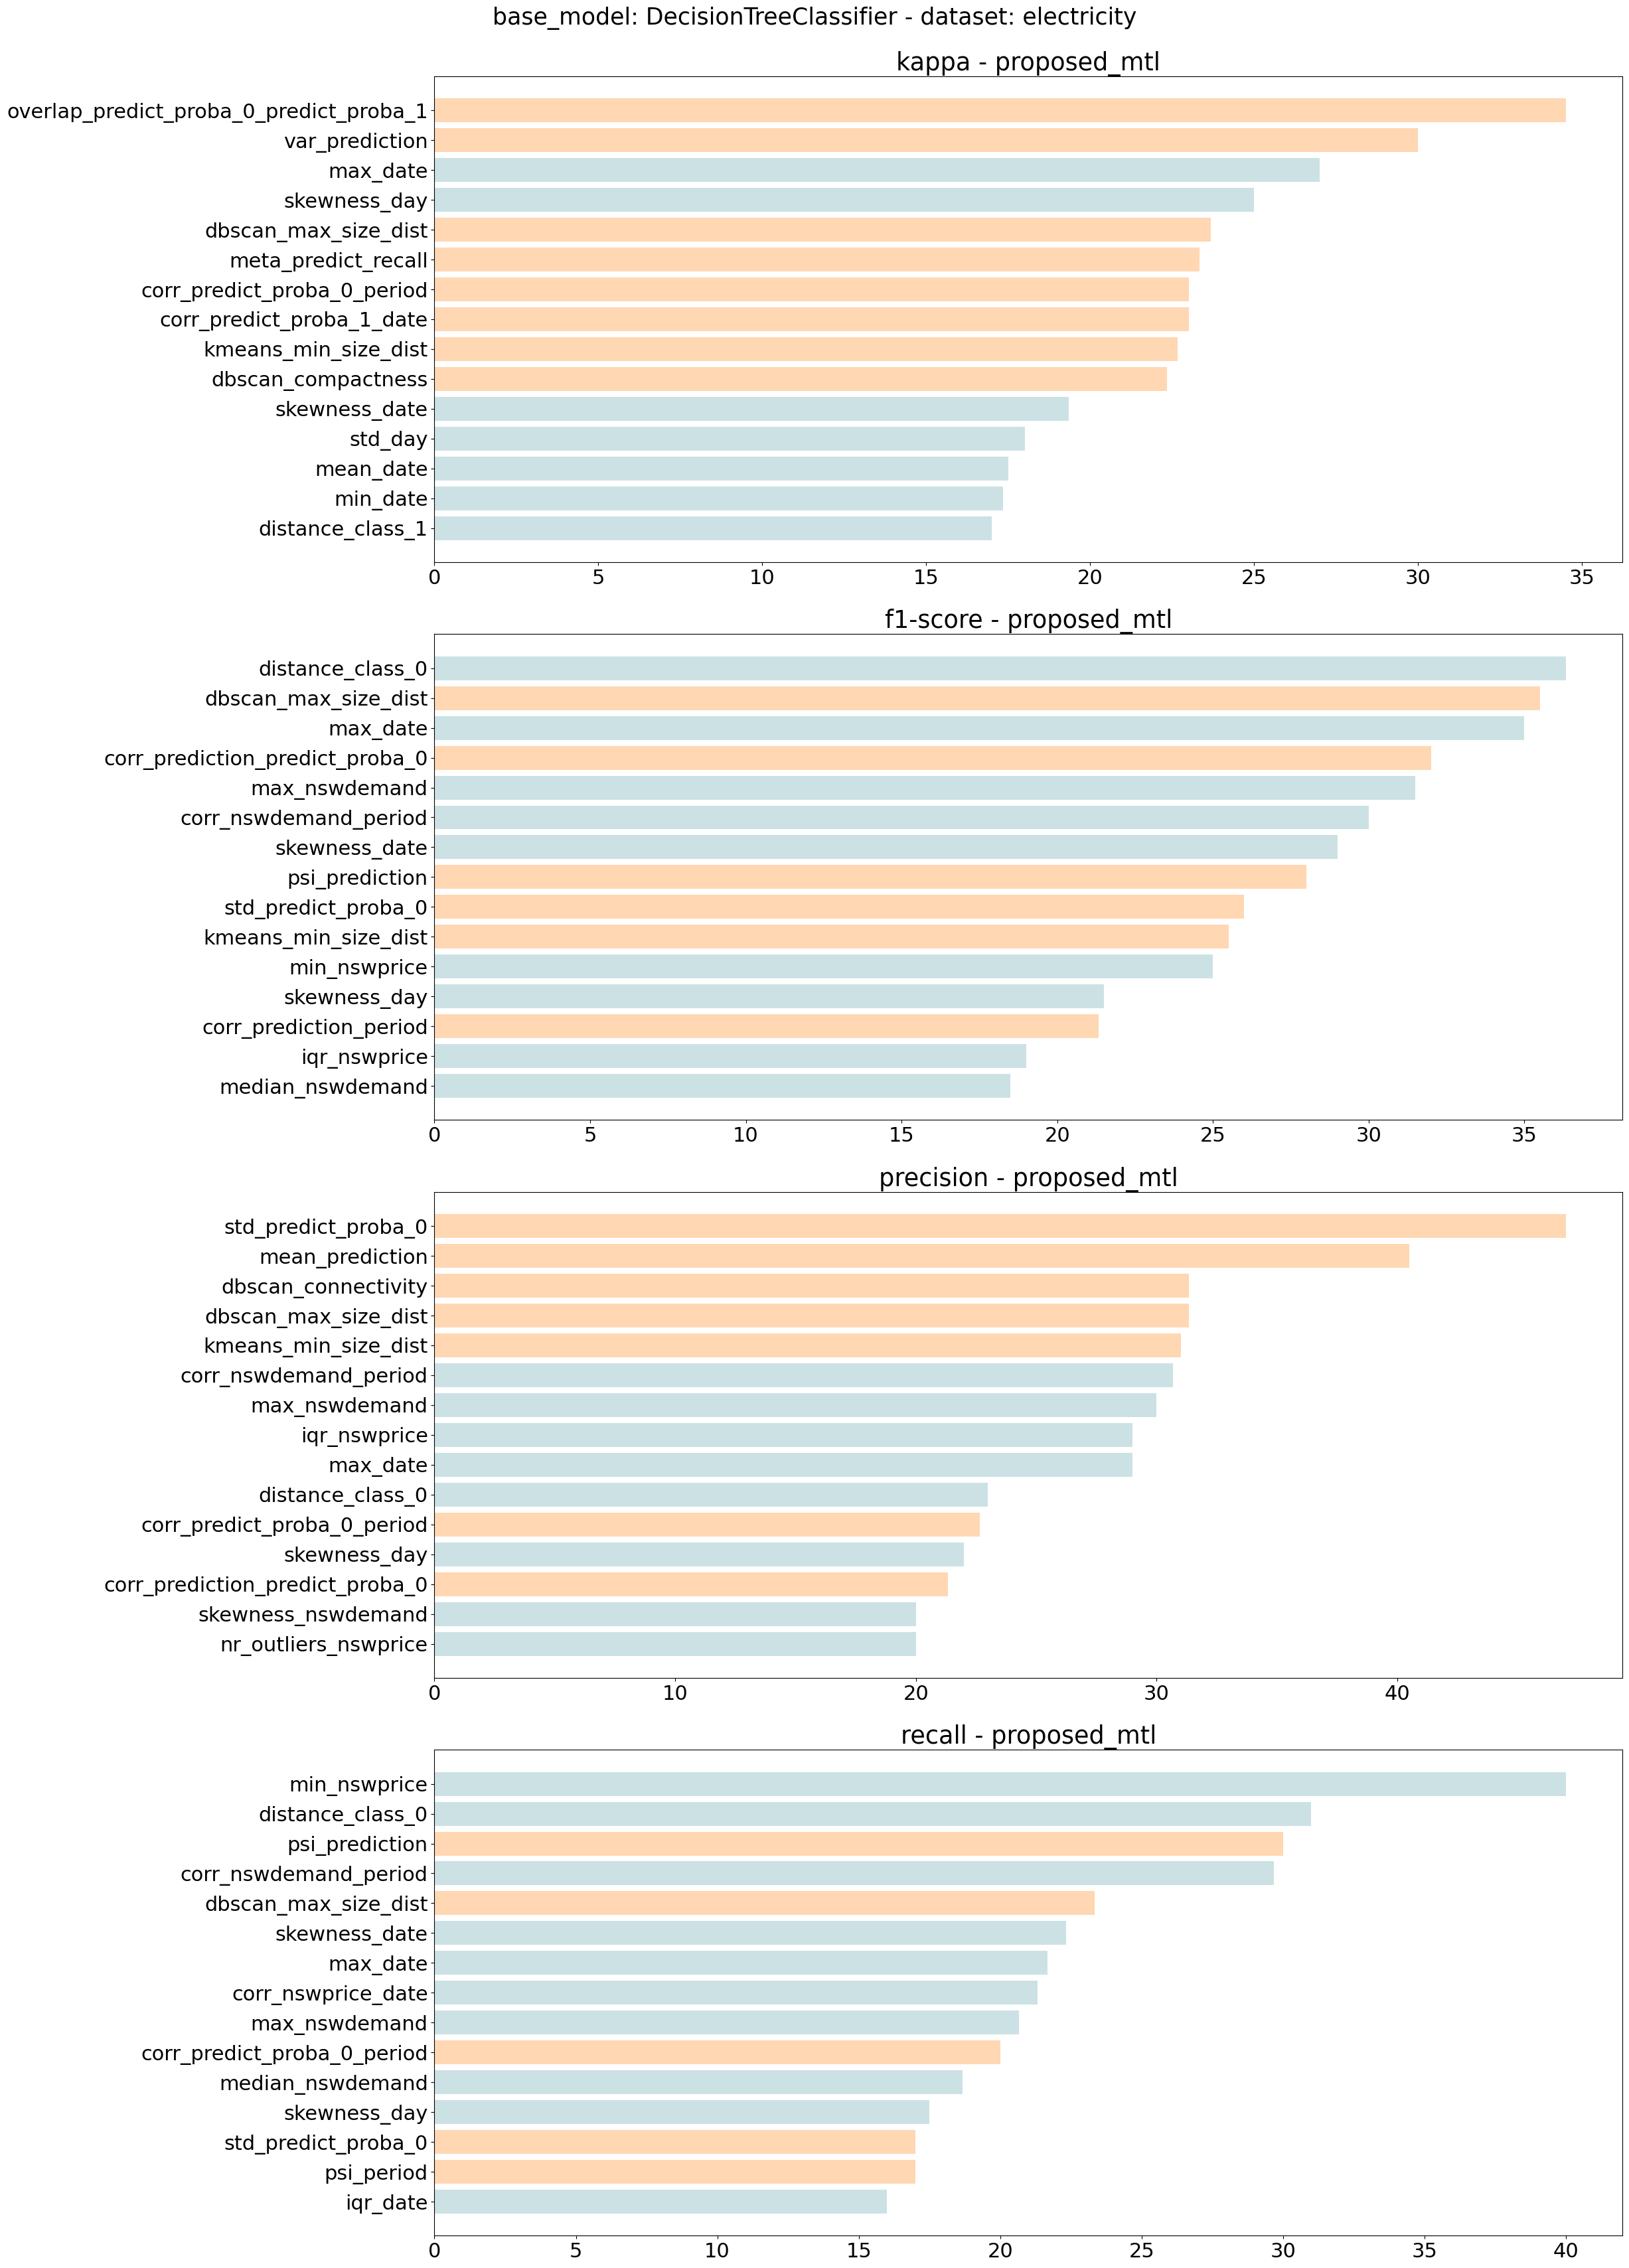

In [15]:
run(base_model="DecisionTreeClassifier", dataset="electricity", feature_fraction=FINAL_FEATURE_FRACTION["electricity"])

<h3>Random Forest </h3>

Acessando arquivo: /home/henriqueramos_qs/meta-learning-concept-drift/results/fernanda/results_importances/base_model: RandomForestClassifier - dataset: electricity - select_k_features: 15.json


/tmp/ipykernel_3425149/3236240098.py:31: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  final_df = pd.concat([final_df, importances_df])


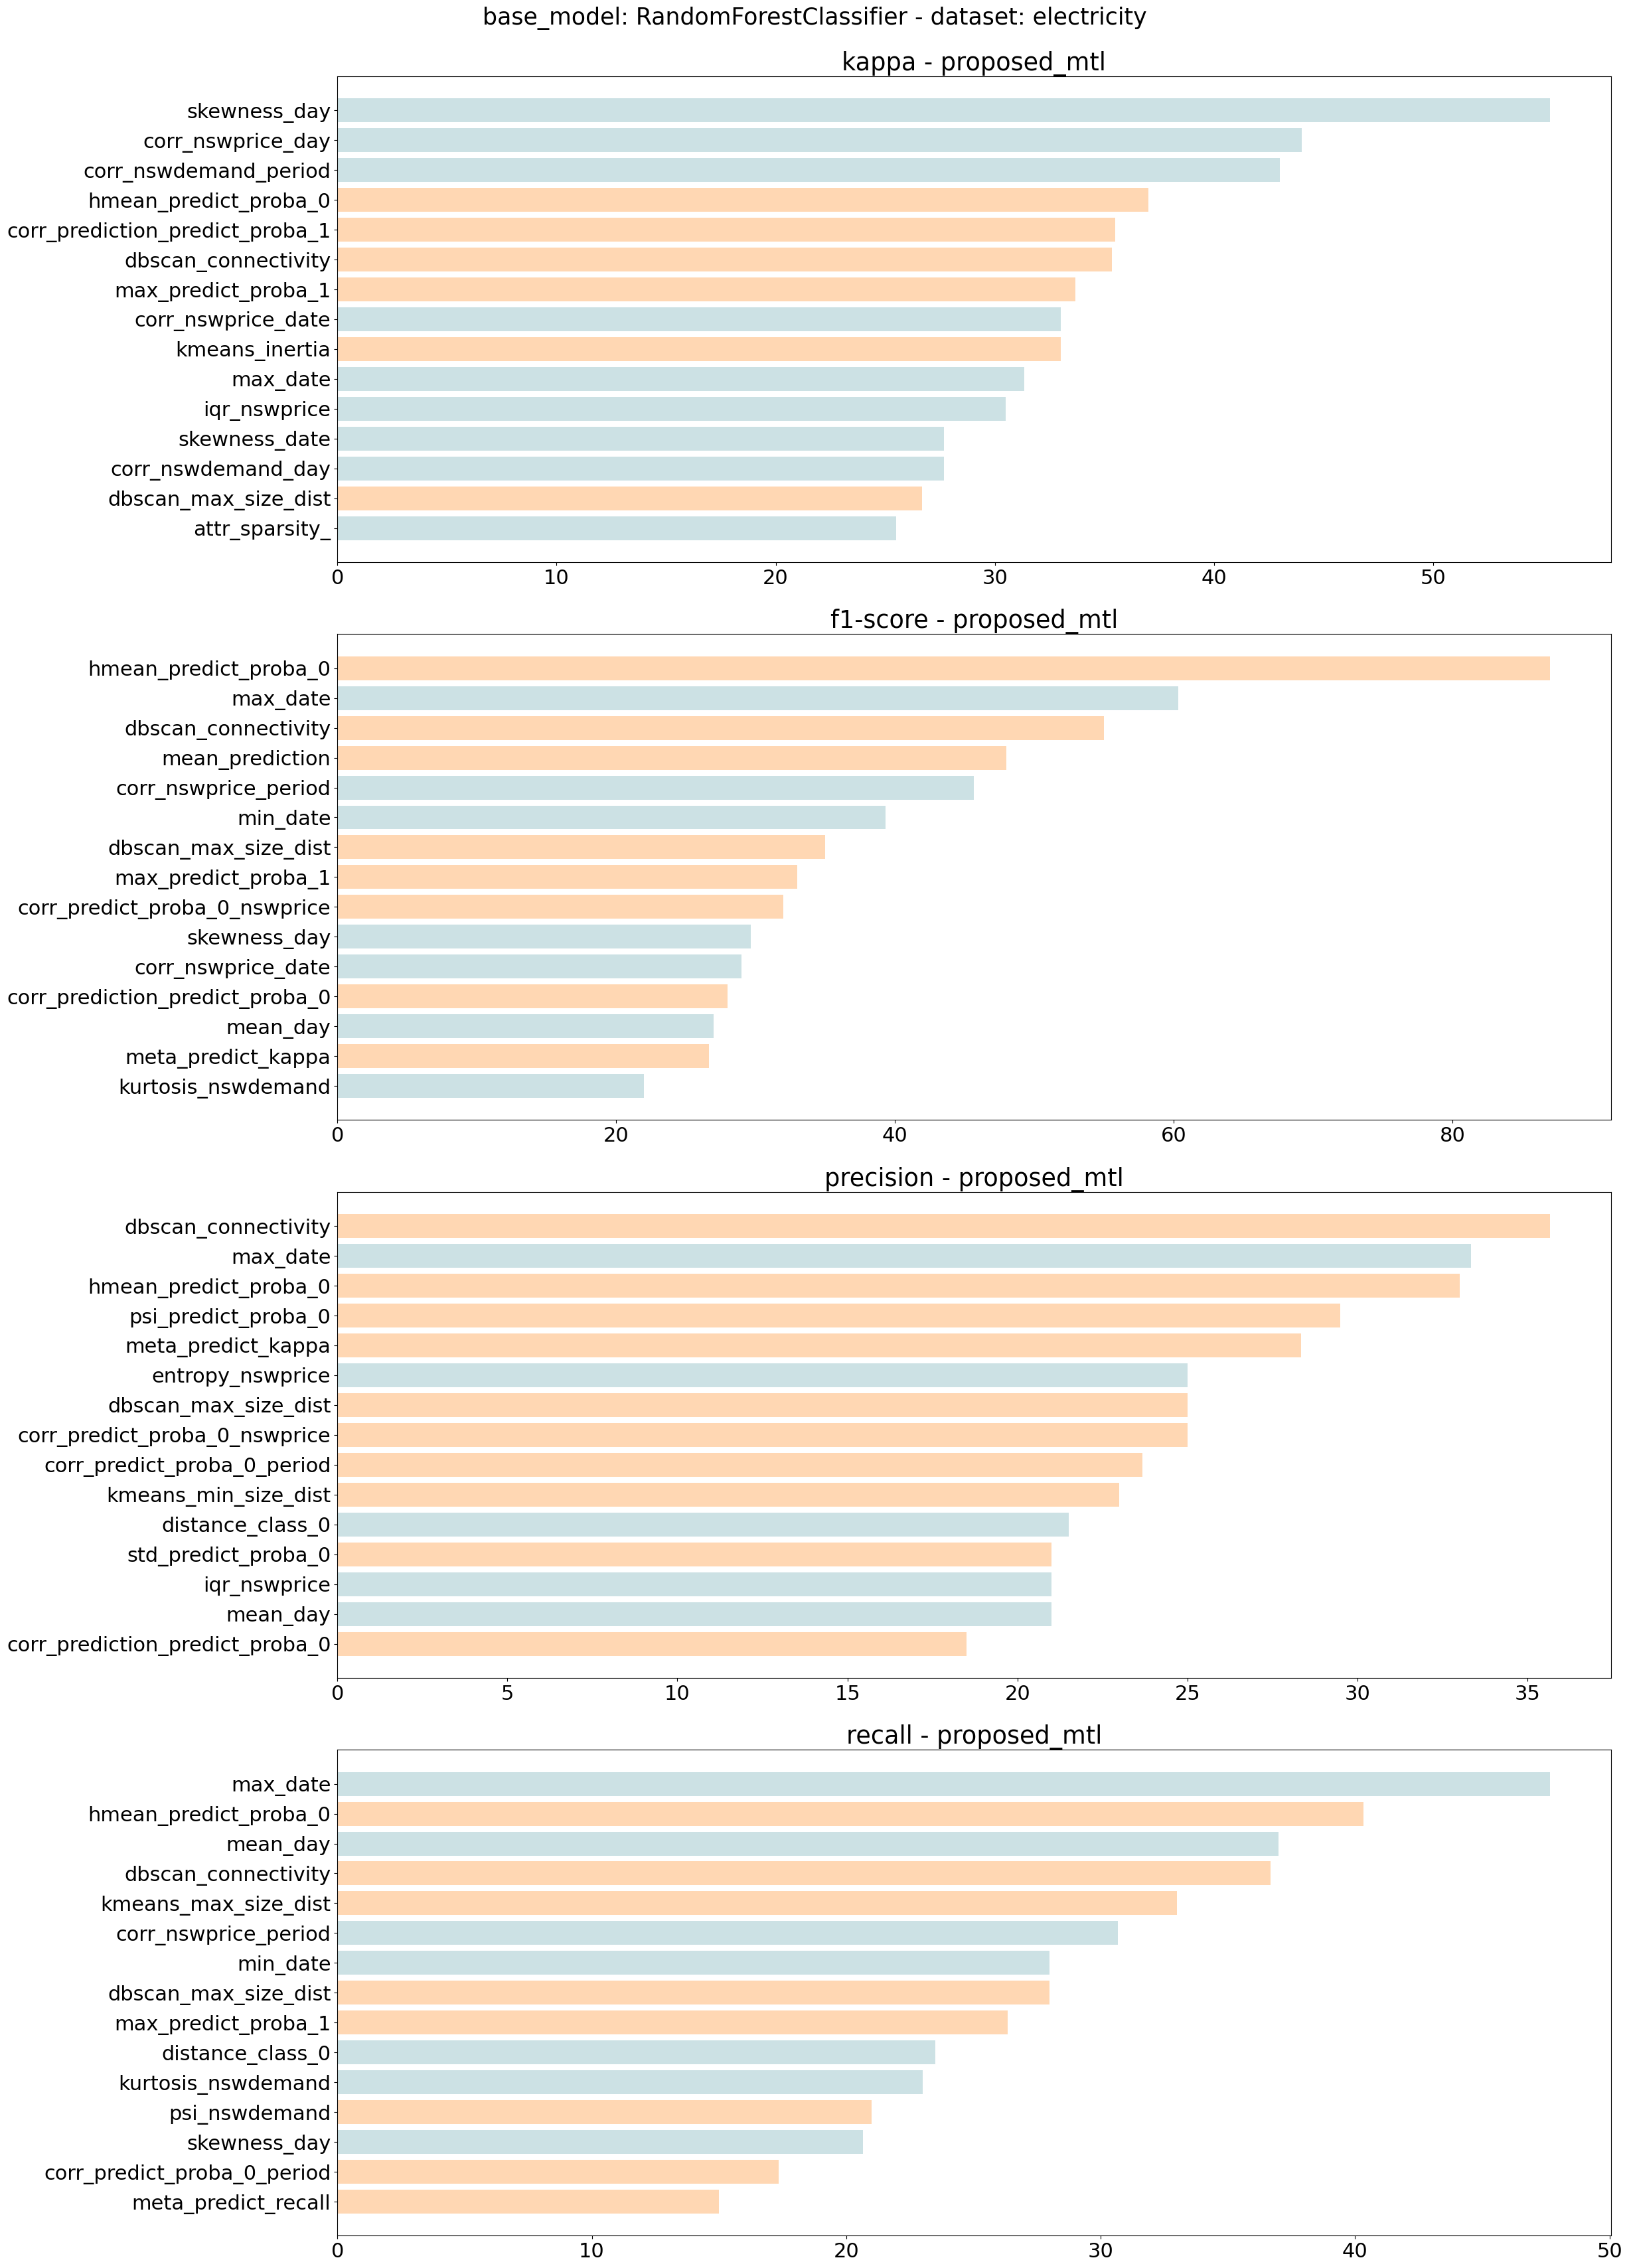

In [5]:
run(base_model="RandomForestClassifier", dataset="electricity", feature_fraction=FINAL_FEATURE_FRACTION["electricity"])

<h3>SVM </h3>

Acessando arquivo: /home/henriqueramos_qs/meta-learning-concept-drift/results/fernanda/results_importances/base_model: SVC - dataset: electricity - select_k_features: 15.json


/tmp/ipykernel_3425149/3236240098.py:31: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  final_df = pd.concat([final_df, importances_df])


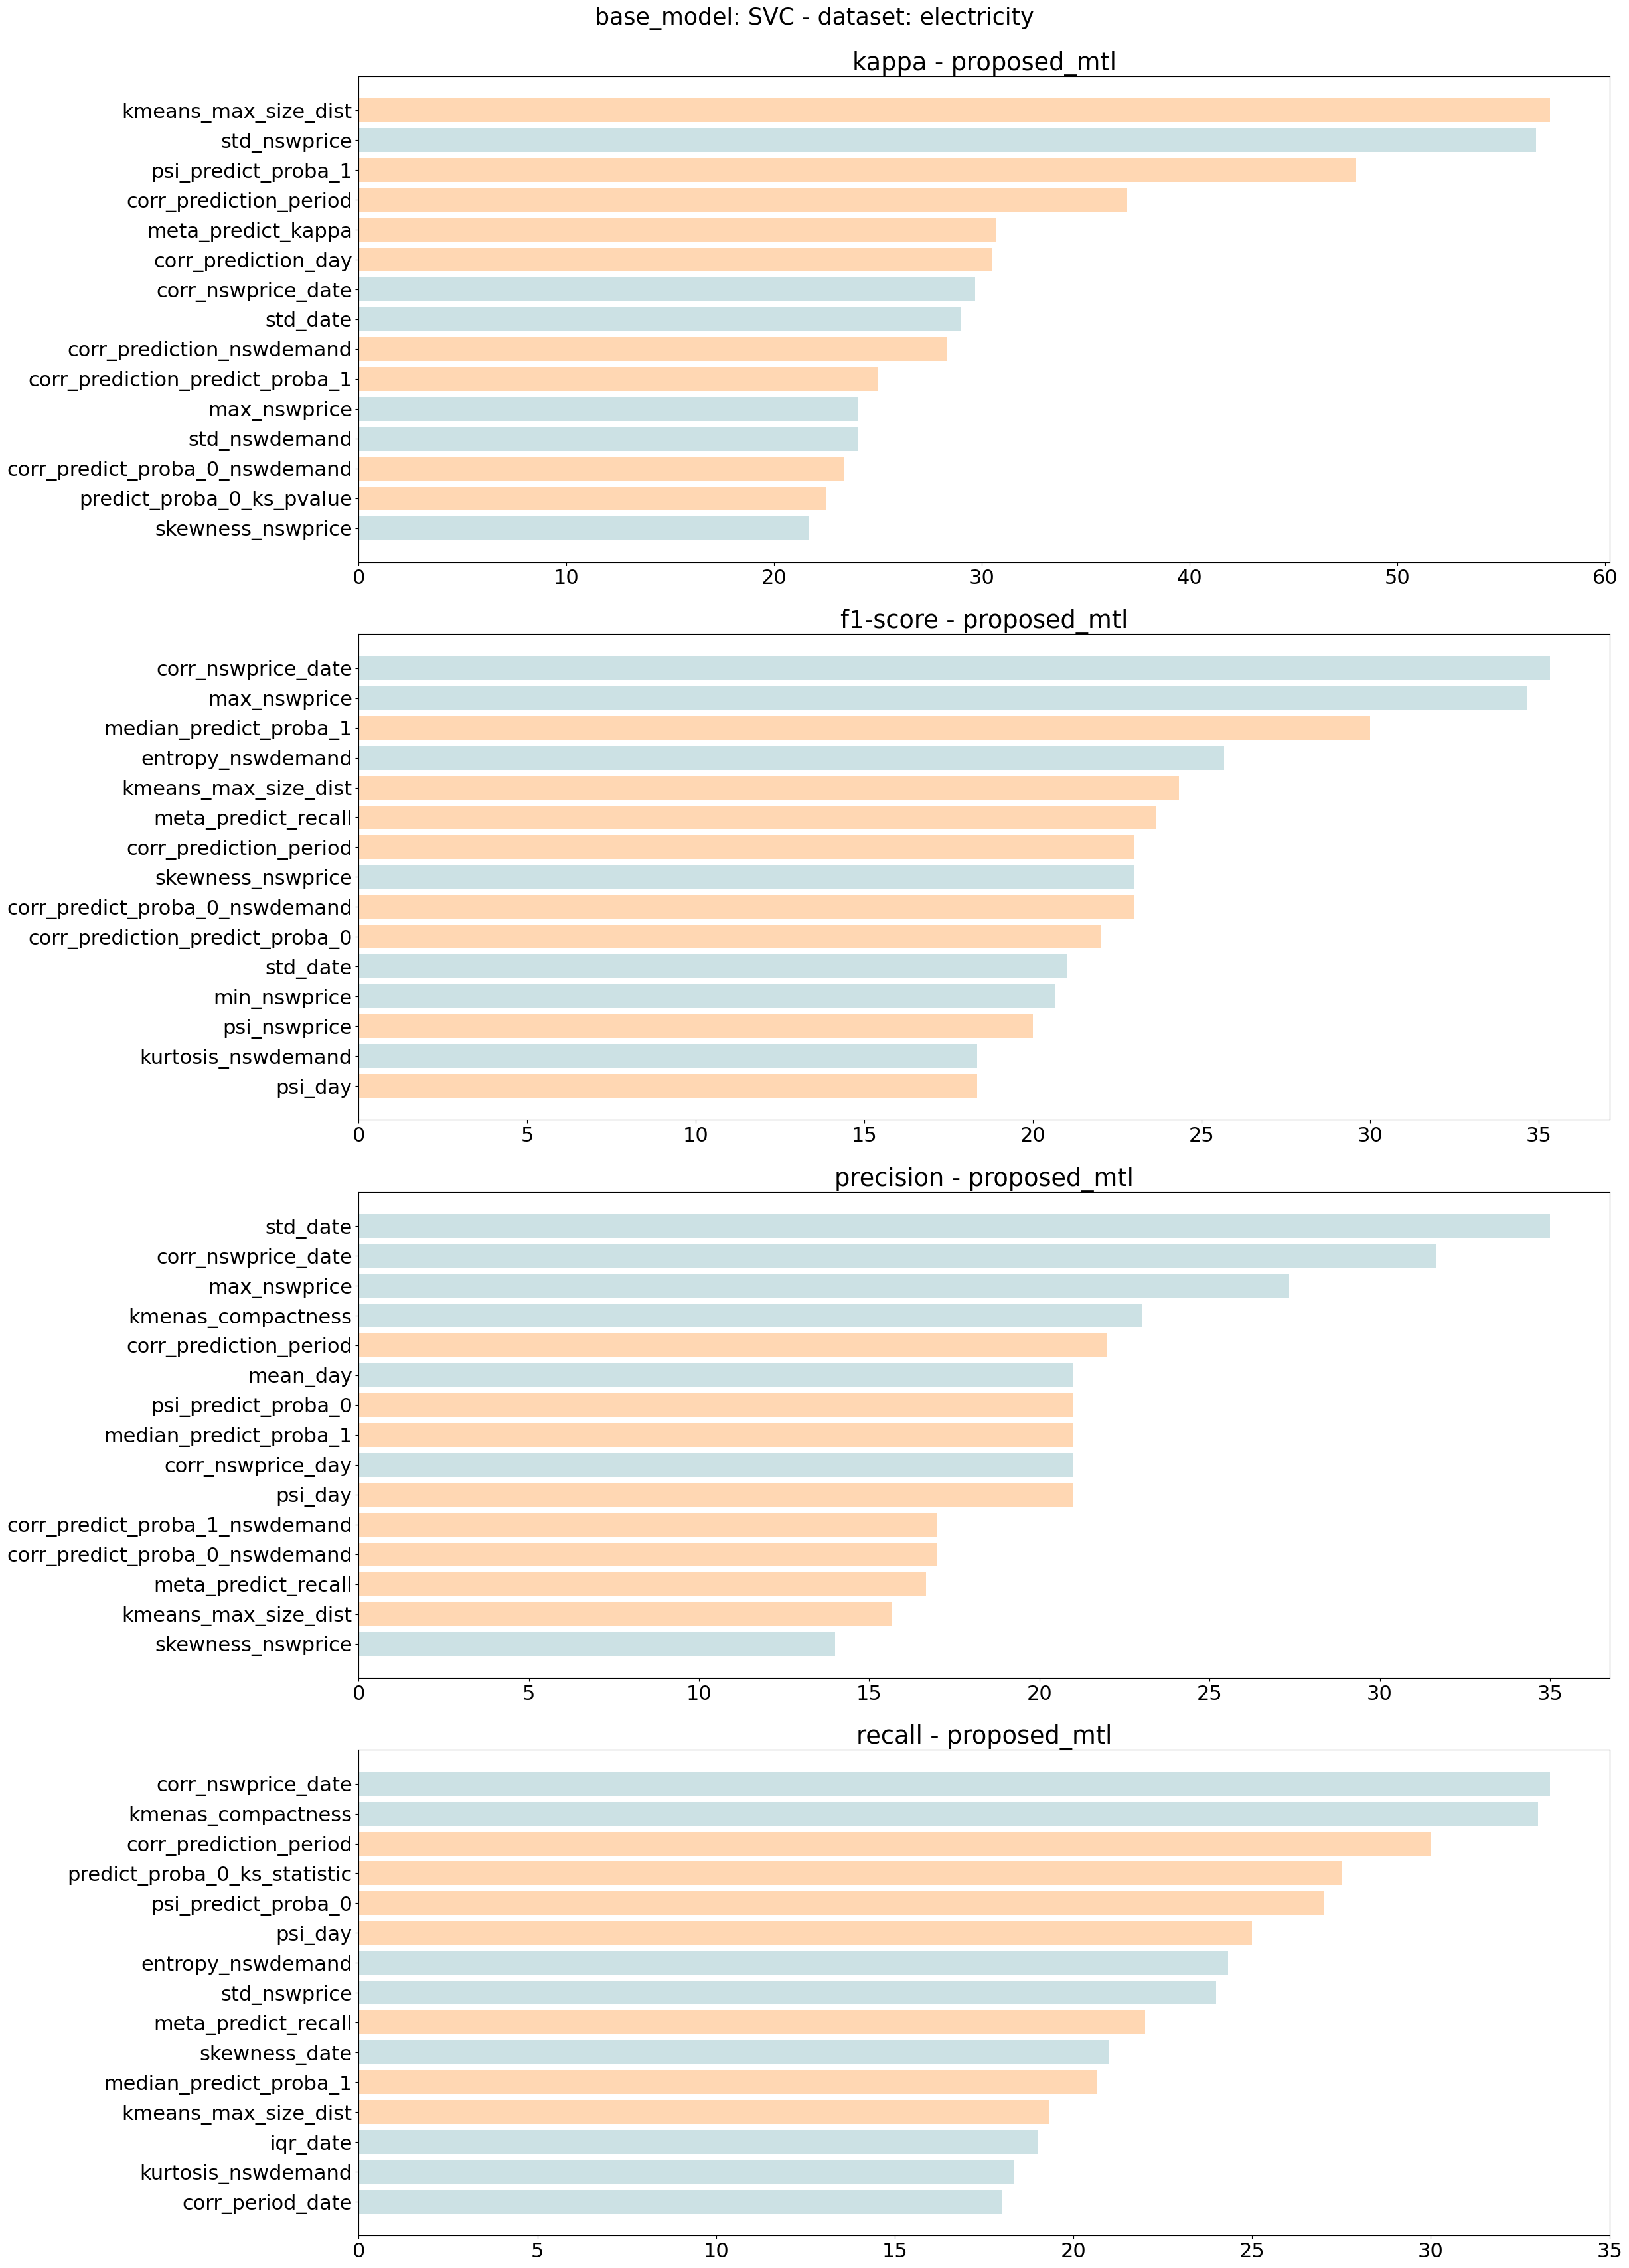

In [6]:
run(base_model="SVC", dataset="electricity", feature_fraction=FINAL_FEATURE_FRACTION["electricity"])

<h3>Logistic Regression</h3>

Acessando arquivo: /home/henriqueramos_qs/meta-learning-concept-drift/results/fernanda/results_importances/base_model: LogisticRegression - dataset: electricity - select_k_features: 15.json


/tmp/ipykernel_3425149/3236240098.py:31: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  final_df = pd.concat([final_df, importances_df])


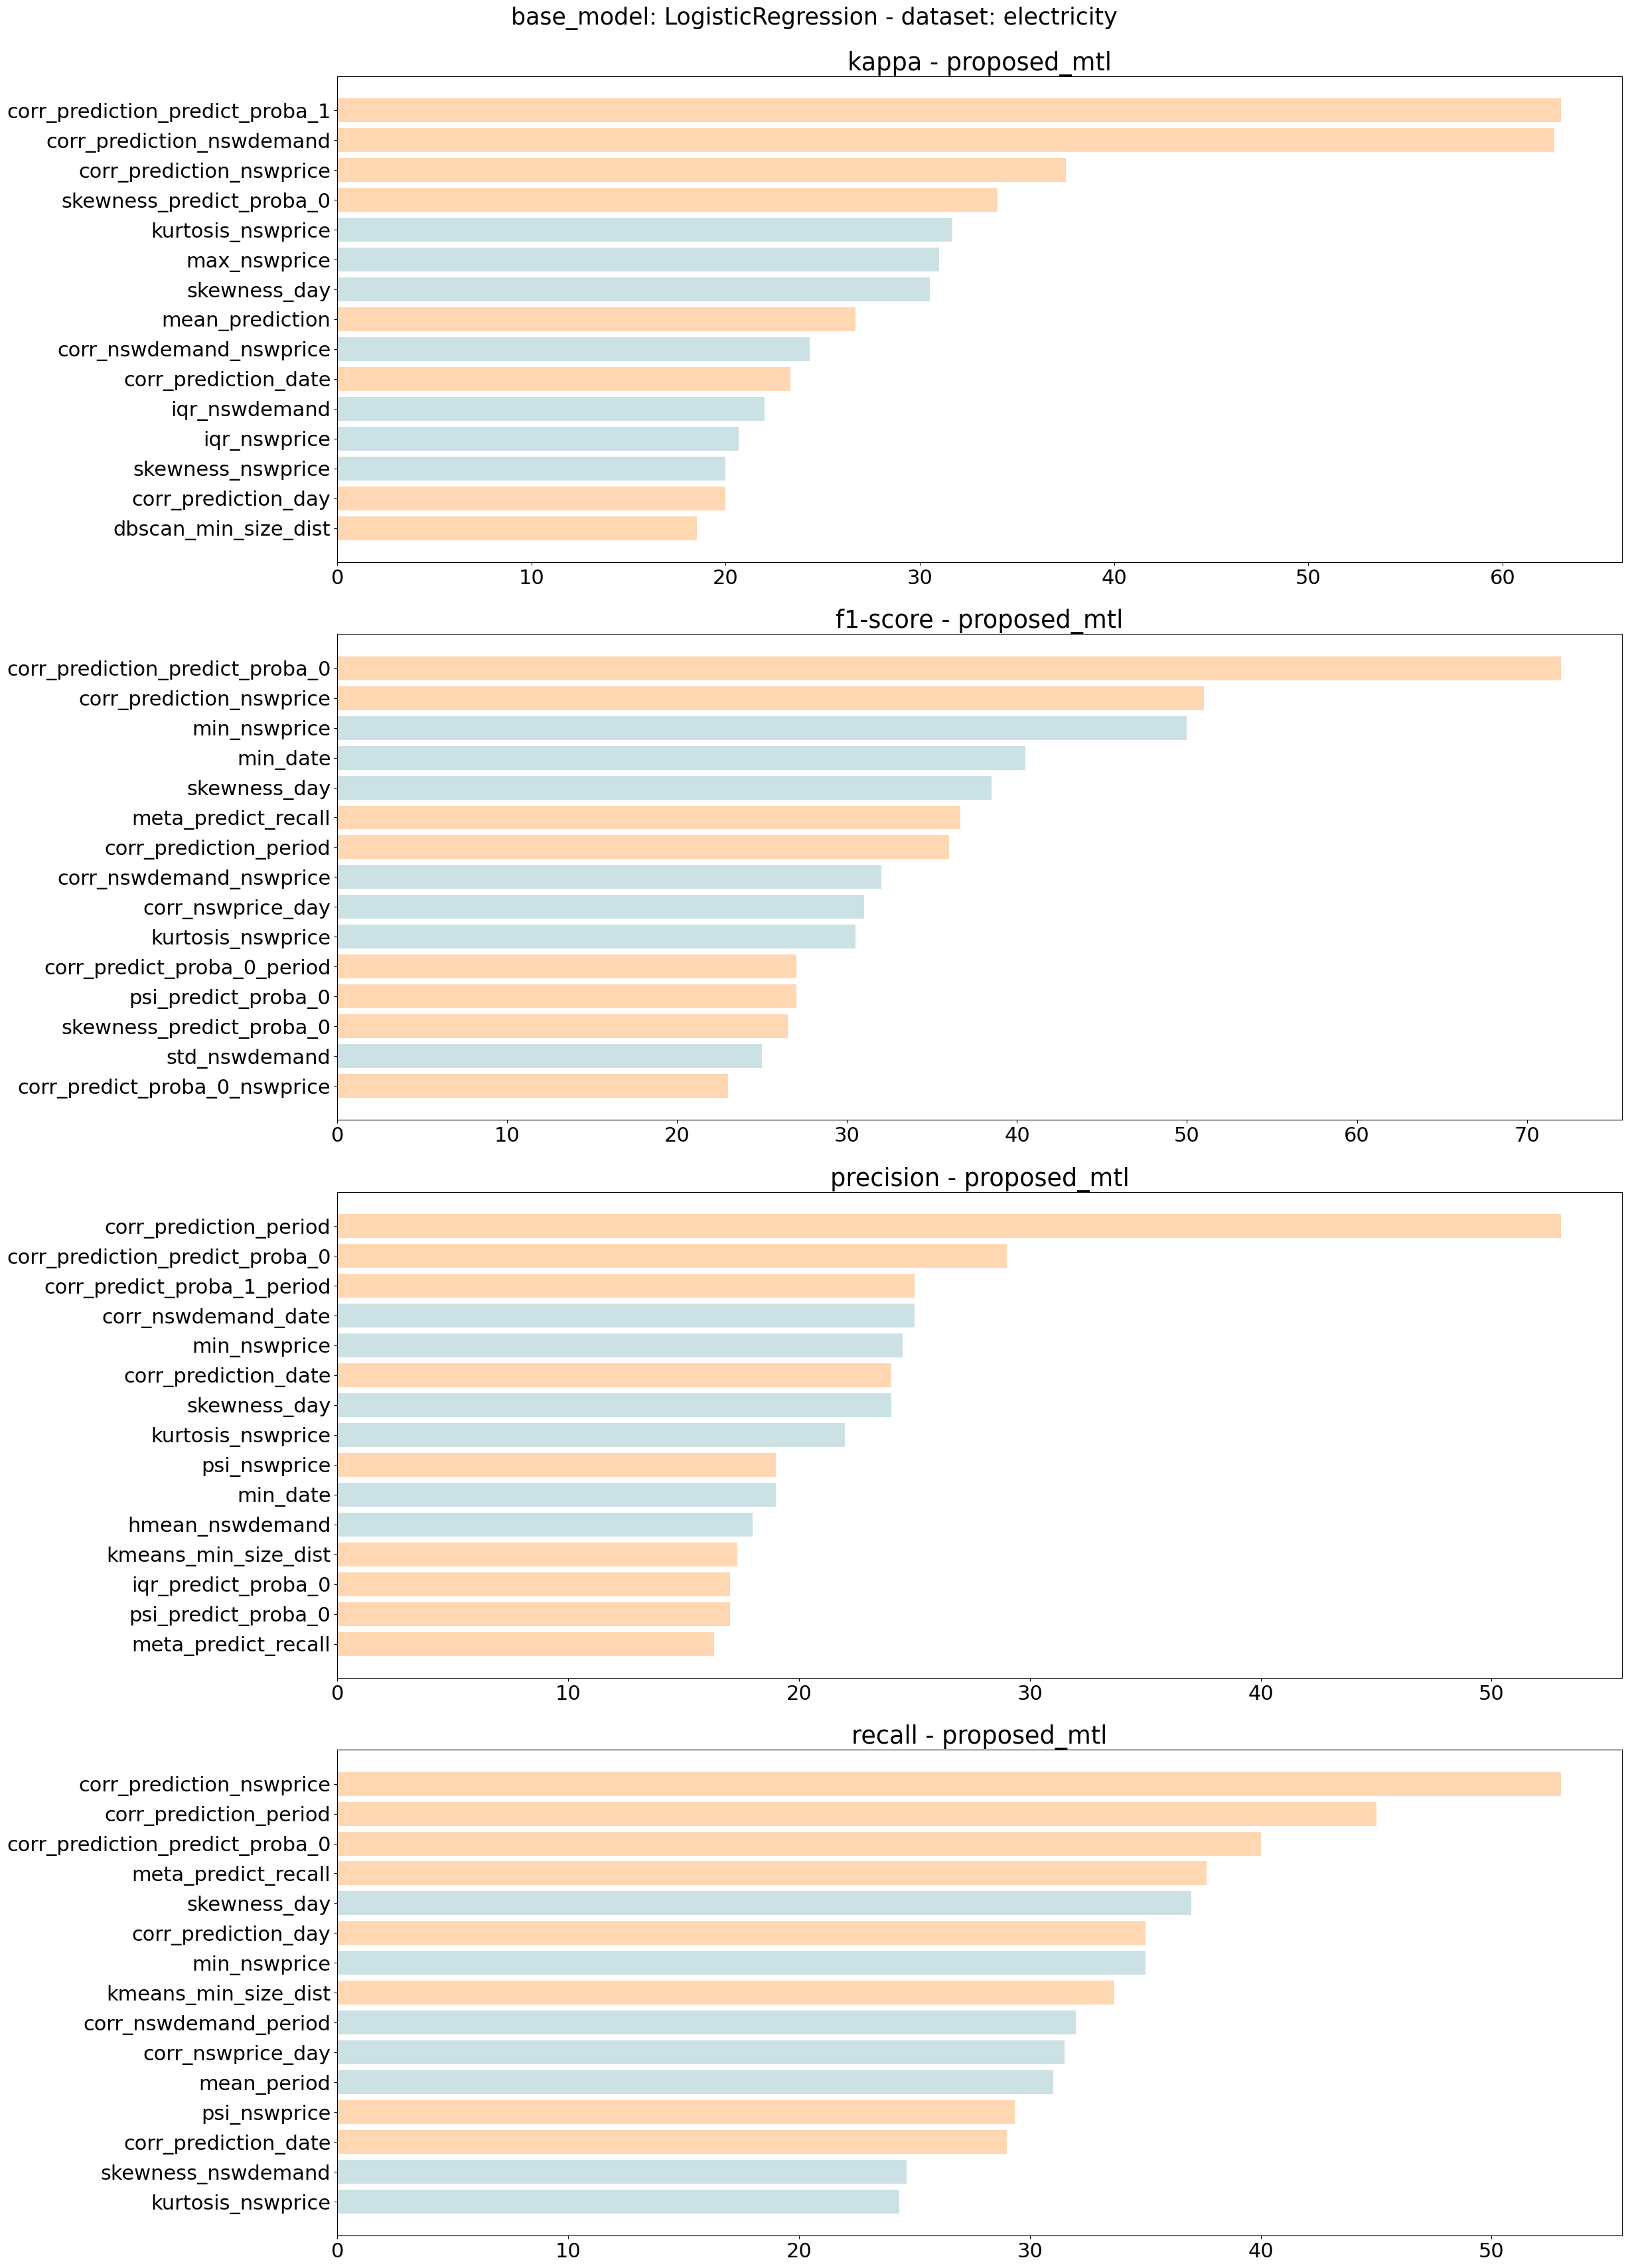

In [7]:
run(base_model="LogisticRegression", dataset="electricity", feature_fraction=FINAL_FEATURE_FRACTION["electricity"])

<h2> Most important features on average</h2>

In [8]:
DRIFT_METRICS_DICT = {
    "psi_": "PsiCalculator",
    "overlap_": "OmvPht",
    "omv_pth": "OmvPht",
    "dc_": "DomainClassifier",
    "_ks_statistic": "SqsiCalculator",
    "_ks_pvalue": "SqsiCalculator",
    "sqsi_drift_flag": "SqsiCalculator",
    "distance_class_": "Udetector",
    "u_detect_": "Udetector",
    "dbscan_": "ClusteringMetrics",
    "kmeans_": "ClusteringMetrics",
    "_uniqueness_ratio": "MiscellaneousMetrics",
    "prop_pca": "MiscellaneousMetrics",
    "_sparsity": "MiscellaneousMetrics",
    "predict": "ScoringMetrics",
    "last": "ScoringMetrics",

    "adwin_": "ADWIN",
    "ddm_": "DDM",
    "hddma_": "HDDM_a",
    "hddmw_": "HDDM_w",
    "kswin_": "KSWIN"

}

BASE_MODELS = [
    "RandomForestClassifier",
    "SVC",
    "LogisticRegression",
    "DecisionTreeClassifier"
]

COLORS = [
    "#ffd7b3", # orange
    "#cce1e4", # green
    "#6aa4c8ff", # blue
    "#d9d9d9", # grey
    "#E08637", # dark orange
    "#6aa4c8ff", # blue
    "#F5E3AD", # yellow
    "#A2D4B0", # greenn diff
    "#5B919A", # dark green
    "#9a5ea1", # purple
    "#e25a5a", # coral red
    "#4a7ebb", # medium blue
    "#f29b9b", # light pink
    "#5cb85c", # vibrant green
    ]

DATASETS = list(FINAL_FEATURE_FRACTION.keys())

def get_mfe_type(row):
    for key, value in DRIFT_METRICS_DICT.items():
        if key in row["feature"]:
            return value
    return "StatsMetrics"

def get_imps(base_model: str="RandomForestClassifier", dataset: str="electricity", feature_fraction: int=100, normalize: bool=True, top_perc_feat: int=None):
    data = _load_data(base_model, dataset, feature_fraction)
    data.pop("auc", None)
    imp_df = _get_mean_importances(data)
    imp_df = imp_df[imp_df["type"] == "proposed_mtl"]
    imp_df["base_model"] = base_model
    imp_df["dataset"] = dataset
    imp_df["mfe_type"] = imp_df.apply(get_mfe_type, axis=1)
    if normalize:
        imp_df["importance"] = (imp_df["importance"]-imp_df["importance"].min())/(imp_df["importance"].max()-imp_df["importance"].min())
    if top_perc_feat:
        if top_perc_feat < 1:
            top_perc_feat = int(top_perc_feat*imp_df.shape[0])
        imp_df = imp_df.sort_values(by=["importance"]).tail(top_perc_feat)
    return imp_df

def plot_bars(importances,  col_name="importance", color="#cce1e4", normalize=True):
    grouped_imps = importances[["mfe_type", col_name]].groupby("mfe_type").sum()
    if normalize:
        total = grouped_imps.sum()
        grouped_imps = grouped_imps/total
    df_plot = grouped_imps[col_name].sort_index()
    df_plot.plot.barh(figsize=(10,6), fontsize=16, color=color)

# TO GET LEGEND
# def plot_bars(importances,  col_name="importance", color="#cce1e4"):
#     grouped_imps = importances[["mfe_type", col_name]].groupby("mfe_type").sum()
#     df_plot = grouped_imps[[col_name]].sort_index()
#     porcent = 100.*df_plot[col_name]/df_plot[col_name].sum()
#     labels = ['{0} - {1:1.1f} %'.format(i,j) for i,j in zip(df_plot.index, porcent)]
#     df_plot.T.plot.barh(figsize=(10,6), fontsize=16, color=color).legend(labels, loc='upper right', prop={'size': 16}, bbox_to_anchor=(1.7, 0.5))

In [9]:
all_imps = pd.DataFrame()
for base_model in BASE_MODELS:
    for dataset in DATASETS:
        this_df = get_imps(base_model=base_model, dataset=dataset, feature_fraction=FINAL_FEATURE_FRACTION[dataset])
        all_imps = pd.concat([all_imps, this_df], ignore_index=True)
all_imps[["mfe_type", "importance"]].groupby("mfe_type").mean()

Acessando arquivo: /home/henriqueramos_qs/meta-learning-concept-drift/results/fernanda/results_importances/base_model: RandomForestClassifier - dataset: powersupply - select_k_features: 50.json
Acessando arquivo: /home/henriqueramos_qs/meta-learning-concept-drift/results/fernanda/results_importances/base_model: RandomForestClassifier - dataset: electricity - select_k_features: 15.json
Acessando arquivo: /home/henriqueramos_qs/meta-learning-concept-drift/results/fernanda/results_importances/base_model: SVC - dataset: powersupply - select_k_features: 50.json


/tmp/ipykernel_3425149/3236240098.py:31: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  final_df = pd.concat([final_df, importances_df])
/tmp/ipykernel_3425149/3236240098.py:31: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  final_df = pd.concat([final_df, importances_df])
/tmp/ipykernel_3425149/3236240098.py:31: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determinin

Acessando arquivo: /home/henriqueramos_qs/meta-learning-concept-drift/results/fernanda/results_importances/base_model: SVC - dataset: electricity - select_k_features: 15.json
Acessando arquivo: /home/henriqueramos_qs/meta-learning-concept-drift/results/fernanda/results_importances/base_model: LogisticRegression - dataset: powersupply - select_k_features: 50.json
Acessando arquivo: /home/henriqueramos_qs/meta-learning-concept-drift/results/fernanda/results_importances/base_model: LogisticRegression - dataset: electricity - select_k_features: 15.json
Acessando arquivo: /home/henriqueramos_qs/meta-learning-concept-drift/results/fernanda/results_importances/base_model: DecisionTreeClassifier - dataset: powersupply - select_k_features: 50.json


/tmp/ipykernel_3425149/3236240098.py:31: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  final_df = pd.concat([final_df, importances_df])
/tmp/ipykernel_3425149/3236240098.py:31: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  final_df = pd.concat([final_df, importances_df])
/tmp/ipykernel_3425149/3236240098.py:31: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determinin

Acessando arquivo: /home/henriqueramos_qs/meta-learning-concept-drift/results/fernanda/results_importances/base_model: DecisionTreeClassifier - dataset: electricity - select_k_features: 15.json


,importance
mfe_type,
ClusteringMetrics,0.104967
DomainClassifier,0.028669
MiscellaneousMetrics,0.044256
OmvPht,0.045844
PsiCalculator,0.092885
ScoringMetrics,0.053014
SqsiCalculator,0.049442
StatsMetrics,0.156048
Udetector,0.107487


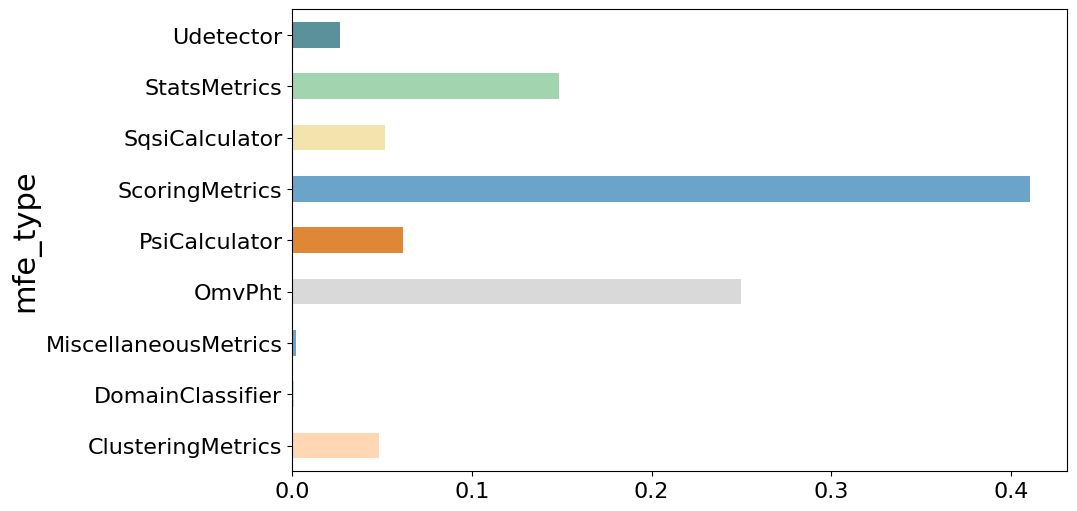

In [10]:
plot_bars(all_imps, color=COLORS)

Count


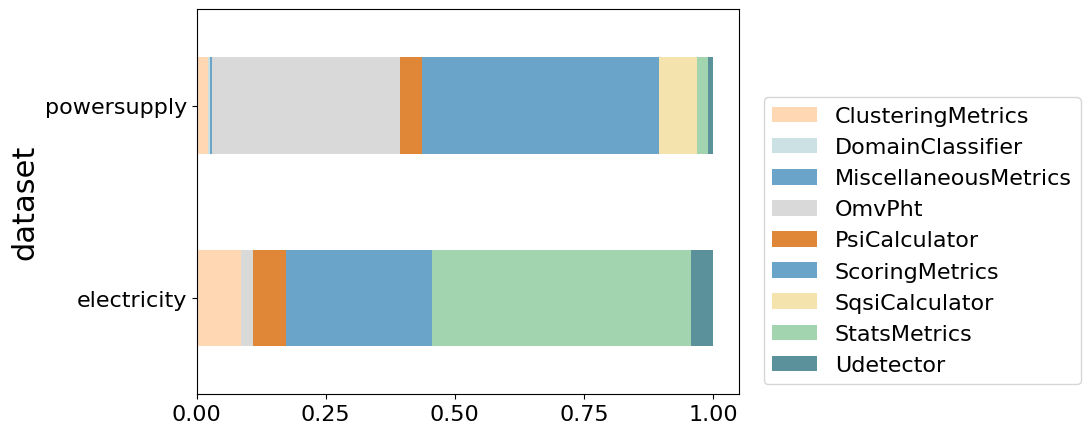

In [11]:
specific_df = all_imps[(all_imps["base_model"] == "RandomForestClassifier") & (all_imps["meta_label"] == "recall")]
feat_count = specific_df.groupby(["dataset", "mfe_type"]).count()[["importance"]].reset_index()
feat_count = feat_count.pivot(index="dataset", columns="mfe_type")
feat_count.columns = feat_count.columns.droplevel()
feat_count = feat_count.div(feat_count.sum(axis=1), axis=0)

feat_count.plot.barh(figsize=(7,5), fontsize=16, color=COLORS, stacked=True).legend(loc='best', prop={'size': 16}, bbox_to_anchor=(1.65, 0.8))

In [12]:
feat_count


mfe_type,ClusteringMetrics,DomainClassifier,MiscellaneousMetrics,OmvPht,PsiCalculator,ScoringMetrics,SqsiCalculator,StatsMetrics,Udetector
dataset,,,,,,,,,
electricity,0.086957,NaN,NaN,0.021739,0.065217,0.282609,NaN,0.500000,0.043478
powersupply,0.022936,0.003058,0.003058,0.365443,0.042813,0.457187,0.074924,0.021407,0.009174


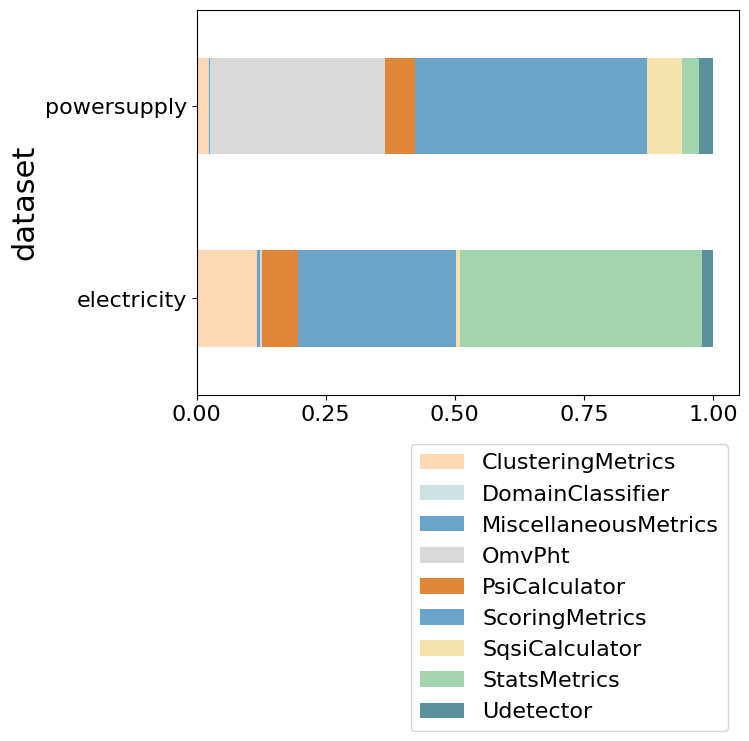

In [13]:
total_imp_dict = all_imps[["dataset", "importance"]].groupby(["dataset"]).sum().to_dict()["importance"]
dataset_df = all_imps[["dataset", "mfe_type", "importance"]].groupby(["dataset", "mfe_type"]).sum().reset_index()
dataset_df["importance"] = dataset_df.apply(lambda  x: x["importance"]/total_imp_dict[x["dataset"]], axis=1)
dataset_df = dataset_df.pivot(index="dataset", columns="mfe_type")
dataset_df.columns = dataset_df.columns.droplevel()
dataset_df.plot.barh(figsize=(7, 5), fontsize=16, color=COLORS, stacked=True).legend(loc='best', prop={'size': 16}, bbox_to_anchor=(1, -0.1))